In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Geometry / grid settings
# =========================
Nx, Ny = 500, 400
xmin, xmax = -60.0, 88.0
ymin, ymax = -60.0, 80.0

In [3]:
x = np.linspace(xmin, xmax, Nx)
y = np.linspace(ymin, ymax, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

In [4]:
# =========================
# Electrode parameters
# =========================
V1 = -9.5                       # left electrode potential
V2 = 9.5                      # right electrode potential

c1 = (7.0, 10.0)               # center of left circle
c2 = (21.0, 10.0)              # center of right circle
R = 0.5                       # radius of both circles

In [5]:

# Masks for the two circular electrodes
r1 = np.sqrt((X - c1[0])**2 + (Y - c1[1])**2)
r2 = np.sqrt((X - c2[0])**2 + (Y - c2[1])**2)

mask1 = r1 <= R
mask2 = r2 <= R

In [6]:
# =========================
# Initialize potential
# =========================
V = np.zeros((Ny, Nx))

# Initial guess: linear interpolation left-to-right
#V[:] = V1 + (V2 - V1) * (X - xmin) / (xmax - xmin)

# Impose electrode potentials
V[mask1] = V1
V[mask2] = V2

# Dirichlet outer boundary: V = 0 far away
V[:, 0]  = 0.0
V[:, -1] = 0.0
V[0, :]  = 0.0
V[-1, :] = 0.0

In [7]:
# Fixed points (electrodes + outer boundary)
fixed = np.zeros_like(V, dtype=bool)
fixed[mask1] = True
fixed[mask2] = True
fixed[:, 0]  = True
fixed[:, -1] = True
fixed[0, :]  = True
fixed[-1, :] = True


In [8]:

# =========================
# Solve Laplace equation
# =========================
max_iter = 10000
tolerance = 1e-5

for it in range(max_iter):
    V_old = V.copy()

    # Jacobi update on interior points
    V[1:-1, 1:-1] = 0.25 * (
        V_old[1:-1, 2:] +    # right
        V_old[1:-1, :-2] +   # left
        V_old[2:, 1:-1] +    # up
        V_old[:-2, 1:-1]     # down
    )

    # Re-impose fixed values
    V[mask1] = V1
    V[mask2] = V2
    V[:, 0]  = V1
    V[:, -1] = V2
    V[0, :]  = V1 + (V2 - V1) * (x - xmin) / (xmax - xmin)
    V[-1, :] = V1 + (V2 - V1) * (x - xmin) / (xmax - xmin)

    # Check convergence
    err = np.max(np.abs(V - V_old))
    if it % 500 == 0:
        print(f"Iteration {it}, max change = {err:.3e}")
    if err < tolerance:
        print(f"Converged in {it} iterations, max change = {err:.3e}")
        break
else:
    print(f"Did not fully converge after {max_iter} iterations. Final error = {err:.3e}")

Iteration 0, max change = 9.500e+00
Iteration 500, max change = 6.510e-03
Iteration 1000, max change = 3.186e-03
Iteration 1500, max change = 2.091e-03
Iteration 2000, max change = 1.548e-03
Iteration 2500, max change = 1.224e-03
Iteration 3000, max change = 1.009e-03
Iteration 3500, max change = 8.565e-04
Iteration 4000, max change = 7.427e-04
Iteration 4500, max change = 6.546e-04
Iteration 5000, max change = 5.845e-04
Iteration 5500, max change = 5.274e-04
Iteration 6000, max change = 4.802e-04
Iteration 6500, max change = 4.404e-04
Iteration 7000, max change = 4.067e-04
Iteration 7500, max change = 3.777e-04
Iteration 8000, max change = 3.527e-04
Iteration 8500, max change = 3.308e-04
Iteration 9000, max change = 3.117e-04
Iteration 9500, max change = 2.948e-04
Did not fully converge after 10000 iterations. Final error = 2.798e-04


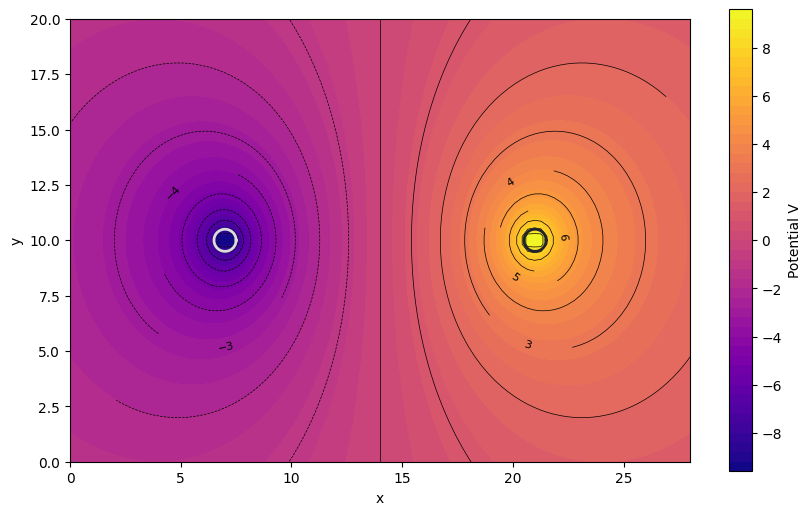

In [15]:
# =========================
# Plot equipotential lines
# =========================
plt.figure(figsize=(10, 6))

# Filled contour
cf = plt.contourf(X, Y, V, levels=50, cmap='plasma')
plt.colorbar(cf, label='Potential V')

# Equipotential lines
cs = plt.contour(X, Y, V, levels=20, colors='k', linewidths=0.5)
plt.clabel(cs, inline=True, fontsize=8)

# Draw electrode boundaries
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(c1[0] + R*np.cos(theta), c1[1] + R*np.sin(theta), "gainsboro", linewidth=2)
plt.plot(c2[0] + R*np.cos(theta), c2[1] + R*np.sin(theta), "#232330", linewidth=2)

plt.gca().set_aspect('equal')
plt.xlim(0, 28)
plt.ylim(0, 20)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [10]:
fieldGradient = -np.array(np.gradient(V))

In [11]:
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

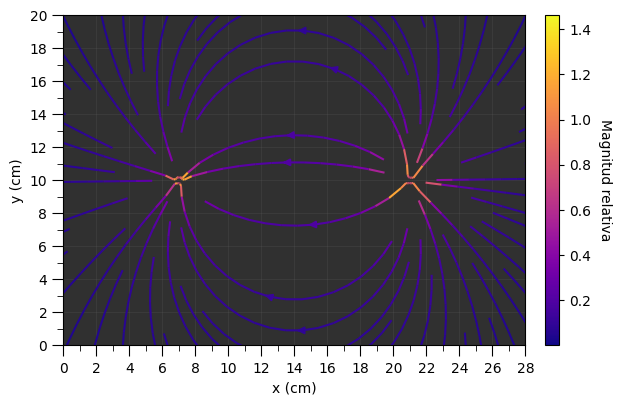

In [12]:
fig, ax = plt.subplots()

divider = make_axes_locatable(ax)

#skip = (slice(None, None, 20), slice(None, None, 20))
#ax.quiver(Y[skip],X[skip], normalizedFieldGradientV[skip], normalizedFieldGradientU[skip], fieldGradient[1][skip]*fieldGradient[0][skip], angles='xy', scale_units='xy', scale = 1, cmap = 'rainbow', pivot = "mid")
isStreamlineBroken = True


ax.set_xlim(0, 28)
ax.set_ylim(0, 20)

normalizationFactor = np.max(fieldGradient[1]*fieldGradient[0])

stream = plt.streamplot(X,Y,fieldGradient[1], fieldGradient[0],
               color = np.sqrt(fieldGradient[1]**2+fieldGradient[0]**2),
               density = 5, cmap = "plasma",
               broken_streamlines = isStreamlineBroken,
               )
#ax.scatter(chargePositions[:,0], chargePositions[:,1], c = "gainsboro", zorder = 10)

cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(stream.lines, cax=cax)
cbar.set_label('Magnitud relativa',rotation=-90,  labelpad=15)

ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#666666", zorder = 10, alpha = 0.2, ls = "solid")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

ax.set_aspect("equal")

ax.set_facecolor('#303030')


plt.savefig(f"casoUnoCampoElectricoDipolo{isStreamlineBroken}.png", dpi = 300)
plt.show()